# LSTM Sentiment Analysis using PyTorch
Dataset: IMDB Movie Reviews

Goal: Binary classification (positive/negative)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imported necessary libraries.

## Load Dataset

In [ ]:
dataset_path = "aclImdb"

train_pos_path = os.path.join(dataset_path, "train/pos")
train_neg_path = os.path.join(dataset_path, "train/neg")

test_pos_path = os.path.join(dataset_path, "test/pos")
test_neg_path = os.path.join(dataset_path, "test/neg")

Dataset paths initialized.

In [3]:
def load_reviews(folder, label):
    
    reviews = []
    labels = []

    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)

        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()

        reviews.append(text)
        labels.append(label)

    return reviews, labels

In [ ]:
train_pos_reviews, train_pos_labels = load_reviews(train_pos_path, 1)
train_neg_reviews, train_neg_labels = load_reviews(train_neg_path, 0)

train_reviews = train_pos_reviews + train_neg_reviews
train_labels = train_pos_labels + train_neg_labels

Loaded training reviews and combined labels.

In [ ]:
test_pos_reviews, test_pos_labels = load_reviews(test_pos_path, 1)
test_neg_reviews, test_neg_labels = load_reviews(test_neg_path, 0)

test_reviews = test_pos_reviews + test_neg_reviews
test_labels = test_pos_labels + test_neg_labels

Loaded test reviews and labels.

In [ ]:
print("Training samples:", len(train_reviews))
print("Test samples:", len(test_reviews))

Displayed number of samples in each set.

In [7]:
print(train_reviews[0])
print(train_labels[0])

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!
1


## Text Preprocessing

In [8]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ashifa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ashifa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ashifa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

In [10]:
def preprocess_text(text):

    # convert to lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return tokens

In [11]:
print(train_reviews[0])

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!


In [12]:
processed = preprocess_text(train_reviews[0])
print(processed[:20])

['bromwell', 'high', 'cartoon', 'comedy', 'ran', 'time', 'programs', 'school', 'life', 'teachers', 'years', 'teaching', 'profession', 'lead', 'believe', 'bromwell', 'highs', 'satire', 'much', 'closer']


In [13]:
train_tokens = [preprocess_text(review) for review in train_reviews]
test_tokens = [preprocess_text(review) for review in test_reviews]

## Build Vocabulary

In [14]:
from collections import Counter

In [15]:
word_counter = Counter()

for tokens in train_tokens:
    word_counter.update(tokens)

In [16]:
max_vocab_size = 10000
most_common_words = word_counter.most_common(max_vocab_size)

In [17]:
vocab = {word: idx+2 for idx, (word, _) in enumerate(most_common_words)}

vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

In [18]:
print("Vocabulary size:", len(vocab))

Vocabulary size: 10002


In [19]:
print(list(vocab.items())[:10])

[('br', 2), ('movie', 3), ('film', 4), ('one', 5), ('like', 6), ('good', 7), ('even', 8), ('would', 9), ('time', 10), ('really', 11)]


## Encode Reviews into number sequence

In [20]:
def encode_tokens(tokens, vocab):
    
    encoded = []
    
    for word in tokens:
        if word in vocab:
            encoded.append(vocab[word])
        else:
            encoded.append(vocab["<UNK>"])
            
    return encoded

In [21]:
example = train_tokens[0]

print(example[:10])
print(encode_tokens(example, vocab)[:10])

['bromwell', 'high', 'cartoon', 'comedy', 'ran', 'time', 'programs', 'school', 'life', 'teachers']
[1, 216, 951, 123, 1941, 10, 5376, 292, 43, 4690]


In [22]:
train_sequences = [encode_tokens(tokens, vocab) for tokens in train_tokens]
test_sequences = [encode_tokens(tokens, vocab) for tokens in test_tokens]

## Pad All Sequences

In [23]:
def pad_sequence(sequence, max_len):
    
    if len(sequence) < max_len:
        sequence = sequence + [0] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
        
    return sequence

In [24]:
max_len = 200

In [25]:
train_padded = [pad_sequence(seq, max_len) for seq in train_sequences]
test_padded = [pad_sequence(seq, max_len) for seq in test_sequences]

In [26]:
print(len(train_padded))
print(len(train_padded[0]))

25000
200


## Convert Data to NumPy Arrays

In [27]:
import numpy as np

X_train = np.array(train_padded)
y_train = np.array(train_labels)

X_test = np.array(test_padded)
y_test = np.array(test_labels)

In [28]:
print(X_train.shape)
print(y_train.shape)

(25000, 200)
(25000,)


## Train / Validation Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42
)

In [30]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (21250, 200)
Validation: (3750, 200)
Test: (25000, 200)


## Convert to PyTorch Tensors

In [31]:
import torch

X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.float32)

## Create PyTorch Dataset

In [32]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):

    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

## Create Dataset Objects

In [33]:
train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)
test_dataset = IMDBDataset(X_test, y_test)

## Create DataLoaders

In [34]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

## Test the Loader

In [35]:
for texts, labels in train_loader:
    print(texts.shape)
    print(labels.shape)
    break

torch.Size([32, 200])
torch.Size([32])


## Architecture of the LSTM model we will implement

```bash
Word Index
   ↓
Embedding Layer
   ↓
LSTM
   ↓
Dropout
   ↓
Fully Connected Layer
   ↓
Sentiment Score
```

In [36]:
import torch.nn as nn

In [37]:
class SentimentLSTM(nn.Module):

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):

        super(SentimentLSTM, self).__init__()

        # converts word indices → dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # LSTM layer
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # dropout to reduce overfitting
        self.dropout = nn.Dropout(0.5)

        # final classifier
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        embedded = self.embedding(x)

        lstm_out, (hidden, cell) = self.lstm(embedded)

        hidden_last = hidden[-1]

        out = self.dropout(hidden_last)

        out = self.fc(out)

        return out

In [38]:
vocab_size = len(vocab)

model = SentimentLSTM(vocab_size)

print(model)

SentimentLSTM(
  (embedding): Embedding(10002, 128)
  (lstm): LSTM(128, 256, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


In [39]:
sample_batch = next(iter(train_loader))[0]

output = model(sample_batch)

print(output.shape)

torch.Size([32, 1])


## PIPELINE WORKFLOW :

```bash
Text
↓
Tokenization
↓
Vocabulary
↓
Numerical Sequences
↓
DataLoader
↓
Embedding
↓
LSTM
↓
Sentiment Prediction
```

## Training the model

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Using device:", device)

Using device: cpu


In [41]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [42]:
epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # --- TRAINING ---
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for texts, labels in train_loader:

        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts).squeeze()

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # --- VALIDATION ---
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for texts, labels in val_loader:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts).squeeze()

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print()

Epoch 1/10
Train Loss: 0.6959 | Train Acc: 0.5048
Val Loss: 0.6918 | Val Acc: 0.5083

Epoch 2/10
Train Loss: 0.6987 | Train Acc: 0.5073
Val Loss: 0.6923 | Val Acc: 0.5088

Epoch 3/10
Train Loss: 0.6947 | Train Acc: 0.4983
Val Loss: 0.6949 | Val Acc: 0.5067

Epoch 4/10
Train Loss: 0.6934 | Train Acc: 0.5085
Val Loss: 0.6930 | Val Acc: 0.5069

Epoch 5/10
Train Loss: 0.6886 | Train Acc: 0.5183
Val Loss: 0.6978 | Val Acc: 0.5005

Epoch 6/10
Train Loss: 0.6777 | Train Acc: 0.5317
Val Loss: 0.7045 | Val Acc: 0.5035

Epoch 7/10
Train Loss: 0.6612 | Train Acc: 0.5470
Val Loss: 0.7176 | Val Acc: 0.5069

Epoch 8/10
Train Loss: 0.6432 | Train Acc: 0.5559
Val Loss: 0.7363 | Val Acc: 0.5059

Epoch 9/10
Train Loss: 0.5361 | Train Acc: 0.7211
Val Loss: 0.5208 | Val Acc: 0.7835

Epoch 10/10
Train Loss: 0.3488 | Train Acc: 0.8576
Val Loss: 0.4345 | Val Acc: 0.8280



## Evaluate On Test Set

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for texts, labels in test_loader:
        
        texts = texts.to(device)
        labels = labels.to(device)
        
        outputs = model(texts).squeeze()
        
        preds = torch.sigmoid(outputs) > 0.5
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

## Calculate Metrics

In [45]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Test Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Test Accuracy: 0.81692
Precision: 0.8222041480276535
Recall: 0.80872
F1 Score: 0.8154063319217584


## Plot Training Curves

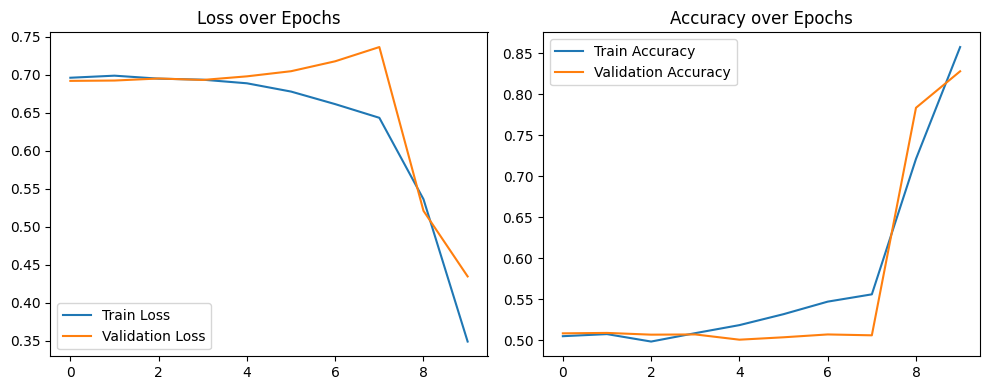

In [53]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()

plt.savefig("plots/training_curves.png")

plt.show()

In [47]:
torch.save(model.state_dict(), "sentiment_lstm_model.pth")

## Error Analysis

In [48]:
misclassified = []

for i in range(len(all_preds)):
    if all_preds[i] != all_labels[i]:
        misclassified.append(i)

In [49]:
for i in misclassified[:5]:
    print("Actual:", all_labels[i])
    print("Predicted:", all_preds[i])
    print("Review:", test_reviews[i][:300])
    print()

Actual: 1.0
Predicted: False
Review: I loved this movie from beginning to end.I am a musician and i let drugs get in the way of my some of the things i used to love(skateboarding,drawing) but my friends were always there for me.Music was like my rehab,life support,and my drug.It changed my life.I can totally relate to this movie and i 

Actual: 1.0
Predicted: False
Review: My wife is a mental health therapist and we watched it from beginning to end. I am the typical man and can not stand chick flicks, but this movie is unbelievable. If you want to see what it is like for someone who is going through these type of struggles, this is the movie for you. As I watched it I

Actual: 1.0
Predicted: False
Review: "Night of the Hunted" stars French porn star Brigitte Lahaie.In fact,many of the cast members in this slow-moving production were porn actors at the time of its frantic filming.This film is certainly different than Rollin's usual lesbian vampire flicks,but it's not as memorable as for

### Error Analysis:

The model misclassified several positive reviews as negative. 
Inspection of these samples reveals common patterns:

1. Mixed sentiment expressions where early sentences contain negative terms such as "struggles", "drugs", or "mental health", even though the overall review is positive.

2. Long reviews where important sentiment cues appear beyond the first 200 tokens due to sequence truncation.

3. Reviews written in analytical or narrative style, where sentiment is implicit rather than expressed through strongly positive words.

These observations suggest that increasing the sequence length or using attention-based models could improve performance.

In [50]:
embeddings = model.embedding.weight.data.cpu().numpy()

In [51]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

reduced_embeddings = tsne.fit_transform(embeddings[:1000])

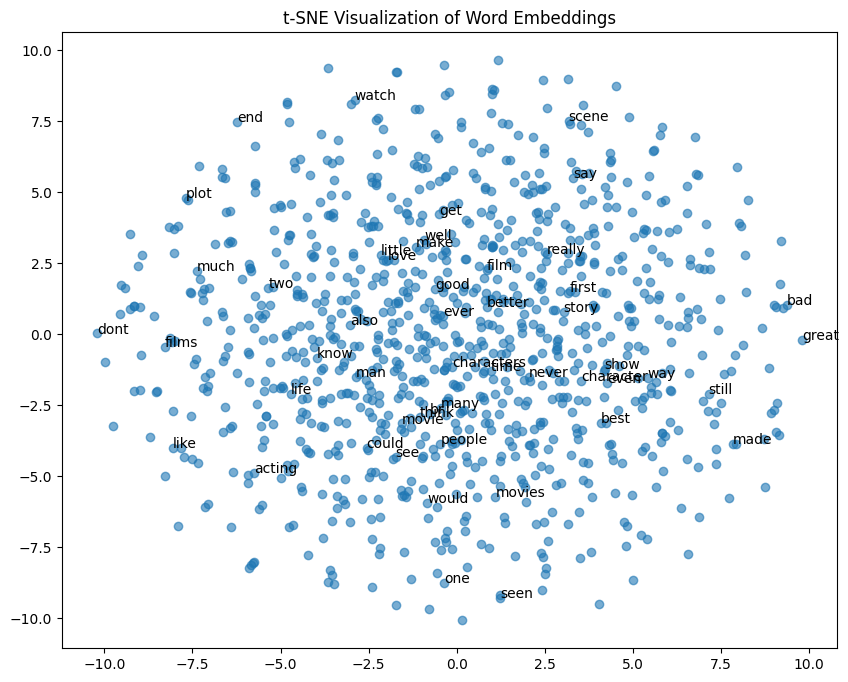

In [54]:
plt.figure(figsize=(10,8))

plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=0.6)

words = list(vocab.keys())[:1000]

for i in range(50):
    plt.annotate(words[i], (reduced_embeddings[i,0], reduced_embeddings[i,1]))

plt.title("t-SNE Visualization of Word Embeddings")

plt.savefig("plots/tsne_embeddings.png")

plt.show()